# Uncertainty Modeling


## Fetching historical weather data (forecast + actual)
### API Request

In [5]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

from datetime import timedelta

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

variables = ["temperature_2m", "direct_normal_irradiance", "diffuse_radiation", "precipitation", "wind_speed_10m", "wind_direction_10m"]
previous_day_suffix = "_previous_day1"
previous_day_variables = [variable + previous_day_suffix for variable in variables]
all_variables = variables + previous_day_variables

def parse_om_response(response, loc_key=0, model_run_date = None):
    hourly = response.Hourly()
    result_dict = {
    	"date": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
            end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = hourly.Interval()),
            inclusive = "left"
        )
    }
    first_result_dt = result_dict['date'][0]

    def calc_forecast_horizon(val):
        # depending on api used (Previous runs vs single_run)
        # from what I can derive, the previous runs API delivers data in "a constant 24h" horizon, which seems
        # a bit too good to be true (it would require lots of archived model runs)
        # single runs api might be a bit more honest and deliver different horizons for training our model.
        if model_run_date is None:
            return pd.Timedelta(hours=24).total_seconds()
        return (val - model_run_date).total_seconds()
    
    for i, var in enumerate(all_variables):
        result_dict[var] = hourly.Variables(i).ValuesAsNumpy()
    
    result_df = pd.DataFrame(data = result_dict)
    result_df["latitude"] = response.Latitude()
    result_df["longitude"] = response.Longitude()
    result_df["elevation"] = response.Elevation()
    result_df["loc_key"] = loc_key
    result_df["day_of_year"] = result_df["date"].dt.day_of_year
    result_df["hour_of_day"] = result_df["date"].dt.hour
    result_df["forecast_horizon"] = result_df["date"].apply(calc_forecast_horizon) 
    result_df = result_df.set_index(["date", "loc_key"])
    return result_df

def parse_responses(responses):
    result_df = None
    for i, response in enumerate(responses):
        df = parse_om_response(response, i)
        if result_df is None:
            result_df = df
        else:
            result_df = pd.concat([result_df,df])
    return result_df

    
        
def split_x_y(df, variable):
    y = df[variable]
    context_variables = ['latitude', 'longitude', 'elevation', 'day_of_year', 'hour_of_day', 'forecast_horizon']
    X = df.reset_index(drop=True)[previous_day_variables + context_variables]
    return X,y

    
# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://previous-runs-api.open-meteo.com/v1/forecast"

min_lat = 45
max_lat = 55
min_lon = 5
max_lon = 15
grid_count = 4
lat_coords = []
lon_coords = []

for i_lat in range(0, grid_count):
    lat = min_lat + i_lat*(max_lat - min_lat)/(grid_count - 1)
    for i_lon in range(0, grid_count):
        lon = min_lon + i_lon*(max_lon - min_lon)/(grid_count - 1)
        lat_coords.append(lat)
        lon_coords.append(lon)




[45.0, 45.0, 45.0, 45.0, 48.333333333333336, 48.333333333333336, 48.333333333333336, 48.333333333333336, 51.666666666666664, 51.666666666666664, 51.666666666666664, 51.666666666666664, 55.0, 55.0, 55.0, 55.0]


,temperature_2m,direct_normal_irradiance,diffuse_radiation,precipitation,wind_speed_10m,wind_direction_10m,temperature_2m_previous_day1,direct_normal_irradiance_previous_day1,diffuse_radiation_previous_day1,precipitation_previous_day1,wind_speed_10m_previous_day1,wind_direction_10m_previous_day1,latitude,longitude,elevation,day_of_year,hour_of_day,forecast_horizon
count,18048.000000,18048.000000,18048.000000,18048.000000,18048.000000,18048.000000,18048.000000,18048.000000,18048.000000,18048.000000,18048.000000,18048.000000,18048.000000,18048.000000,18048.000000,18048.000000,18048.000000,18048.0
mean,19.972021,245.950653,95.174431,0.072684,12.575133,193.836182,20.095177,245.569092,95.251259,0.076895,12.453628,192.562912,49.984625,9.999250,257.125000,175.000000,11.500000,86400.0
std,5.931862,288.807617,97.477295,0.808161,9.128596,105.614632,6.066494,288.657684,97.715614,0.692370,9.084559,105.676270,3.704971,3.731547,307.953915,13.565036,6.922378,0.0
min,5.651500,0.000000,0.000000,0.000000,0.000000,0.000000,5.801500,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,4.988000,0.000000,152.000000,0.000000,86400.0
25%,15.616000,0.000000,0.000000,0.000000,6.120000,87.858576,15.661000,0.000000,0.000000,0.000000,5.860375,86.423744,47.505000,7.437500,2.500000,163.000000,5.750000,86400.0
50%,18.950001,88.071003,77.641842,0.000000,10.440001,224.999893,18.950001,86.299557,77.661865,0.000000,10.383987,220.314026,50.000000,10.000000,149.500000,175.000000,11.500000,86400.0
75%,23.516376,497.946999,161.000000,0.000000,16.199999,280.080536,23.645500,498.349594,160.355133,0.000000,16.327497,280.187111,52.435501,12.562500,393.250000,187.000000,17.250000,86400.0
max,39.658497,918.637512,443.000000,46.299999,61.560001,360.000000,40.908497,934.961304,462.000000,29.299999,64.079994,360.000000,55.000000,15.000000,889.000000,198.000000,23.000000,86400.0


## Generate Training Data

In [48]:
params = {
	"latitude": lat_coords,
	"longitude": lon_coords,
	"hourly": all_variables,
	"start_date": "2026-02-01",
	"end_date": "2026-07-17",
}
responses_train = openmeteo.weather_api(url, params = params)

df_train = parse_responses(responses_train)
X_train,y_train = split_x_y(df_train, 'temperature_2m')
df_train.describe()

,temperature_2m,direct_normal_irradiance,diffuse_radiation,precipitation,wind_speed_10m,wind_direction_10m,temperature_2m_previous_day1,direct_normal_irradiance_previous_day1,diffuse_radiation_previous_day1,precipitation_previous_day1,wind_speed_10m_previous_day1,wind_direction_10m_previous_day1,latitude,longitude,elevation,day_of_year,hour_of_day,forecast_horizon
count,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.0
mean,11.835341,196.101730,73.144943,0.074431,13.108891,182.820190,11.883641,197.536240,72.768173,0.074551,13.049502,181.522415,49.984625,9.999250,257.125000,115.000000,11.500000,86400.0
std,8.041477,277.499939,88.340714,0.559893,10.026751,102.658722,8.071571,278.835632,88.064049,0.494588,10.009461,102.959351,3.704897,3.731472,307.947785,48.208259,6.922241,0.0
min,-9.941500,0.000000,0.000000,0.000000,0.000000,0.000000,-11.491500,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,4.988000,0.000000,32.000000,0.000000,86400.0
25%,5.911000,0.000000,0.000000,0.000000,5.860375,85.000000,5.867500,0.000000,0.000000,0.000000,5.760000,83.997772,47.505000,7.437500,2.500000,73.000000,5.750000,86400.0
50%,10.945499,8.282677,30.520231,0.000000,10.446206,197.744766,10.900000,7.647614,30.451722,0.000000,10.440001,194.401115,50.000000,10.000000,149.500000,115.000000,11.500000,86400.0
75%,17.008501,372.700356,129.538643,0.000000,17.208603,270.000000,17.000000,378.430595,129.000000,0.000000,17.280001,270.000000,52.435501,12.562500,393.250000,157.000000,17.250000,86400.0
max,39.658497,961.728821,444.000000,46.299999,75.599998,360.000000,40.908497,959.259705,462.000000,29.299999,71.639999,360.000000,55.000000,15.000000,889.000000,198.000000,23.000000,86400.0


## Generate Test Data

In [49]:

params = {
	"latitude": lat_coords,
	"longitude": lon_coords,
	"hourly": all_variables,
	"start_date": "2025-02-01",
	"end_date": "2025-07-17",
}
responses_test = openmeteo.weather_api(url, params = params)

df_test = parse_responses(responses_test)
df_test.describe()

,temperature_2m,direct_normal_irradiance,diffuse_radiation,precipitation,wind_speed_10m,wind_direction_10m,temperature_2m_previous_day1,direct_normal_irradiance_previous_day1,diffuse_radiation_previous_day1,precipitation_previous_day1,wind_speed_10m_previous_day1,wind_direction_10m_previous_day1,latitude,longitude,elevation,day_of_year,hour_of_day,forecast_horizon
count,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.000000,64128.0
mean,11.354015,195.337982,73.285202,0.066707,13.065406,181.444839,11.376016,197.423660,73.546036,0.069187,13.009230,180.706528,49.984625,9.999250,257.125000,115.000000,11.500000,86400.0
std,7.595369,275.644562,88.066750,0.457256,9.298461,105.281494,7.581320,276.946960,88.440201,0.512065,9.330542,105.873192,3.704897,3.731472,307.947785,48.208259,6.922241,0.0
min,-11.791500,0.000000,0.000000,0.000000,0.000000,0.000000,-11.441500,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,4.988000,0.000000,32.000000,0.000000,86400.0
25%,5.883000,0.000000,0.000000,0.000000,6.130579,80.000000,5.850000,0.000000,0.000000,0.000000,6.120000,79.000000,47.505000,7.437500,2.500000,73.000000,5.750000,86400.0
50%,11.117500,9.438675,31.249474,0.000000,10.799999,196.699326,11.117500,9.810013,32.000000,0.000000,10.799999,196.000000,50.000000,10.000000,149.500000,115.000000,11.500000,86400.0
75%,16.377375,373.874695,130.000000,0.000000,17.433999,270.000000,16.317501,378.531242,130.000000,0.000000,17.462782,271.735657,52.435501,12.562500,393.250000,157.000000,17.250000,86400.0
max,39.043499,952.487732,444.000000,30.100000,63.720001,360.000000,39.143501,979.242615,447.000000,34.200001,64.439995,360.000000,55.000000,15.000000,889.000000,198.000000,23.000000,86400.0


<Axes: xlabel='date', ylabel='error'>

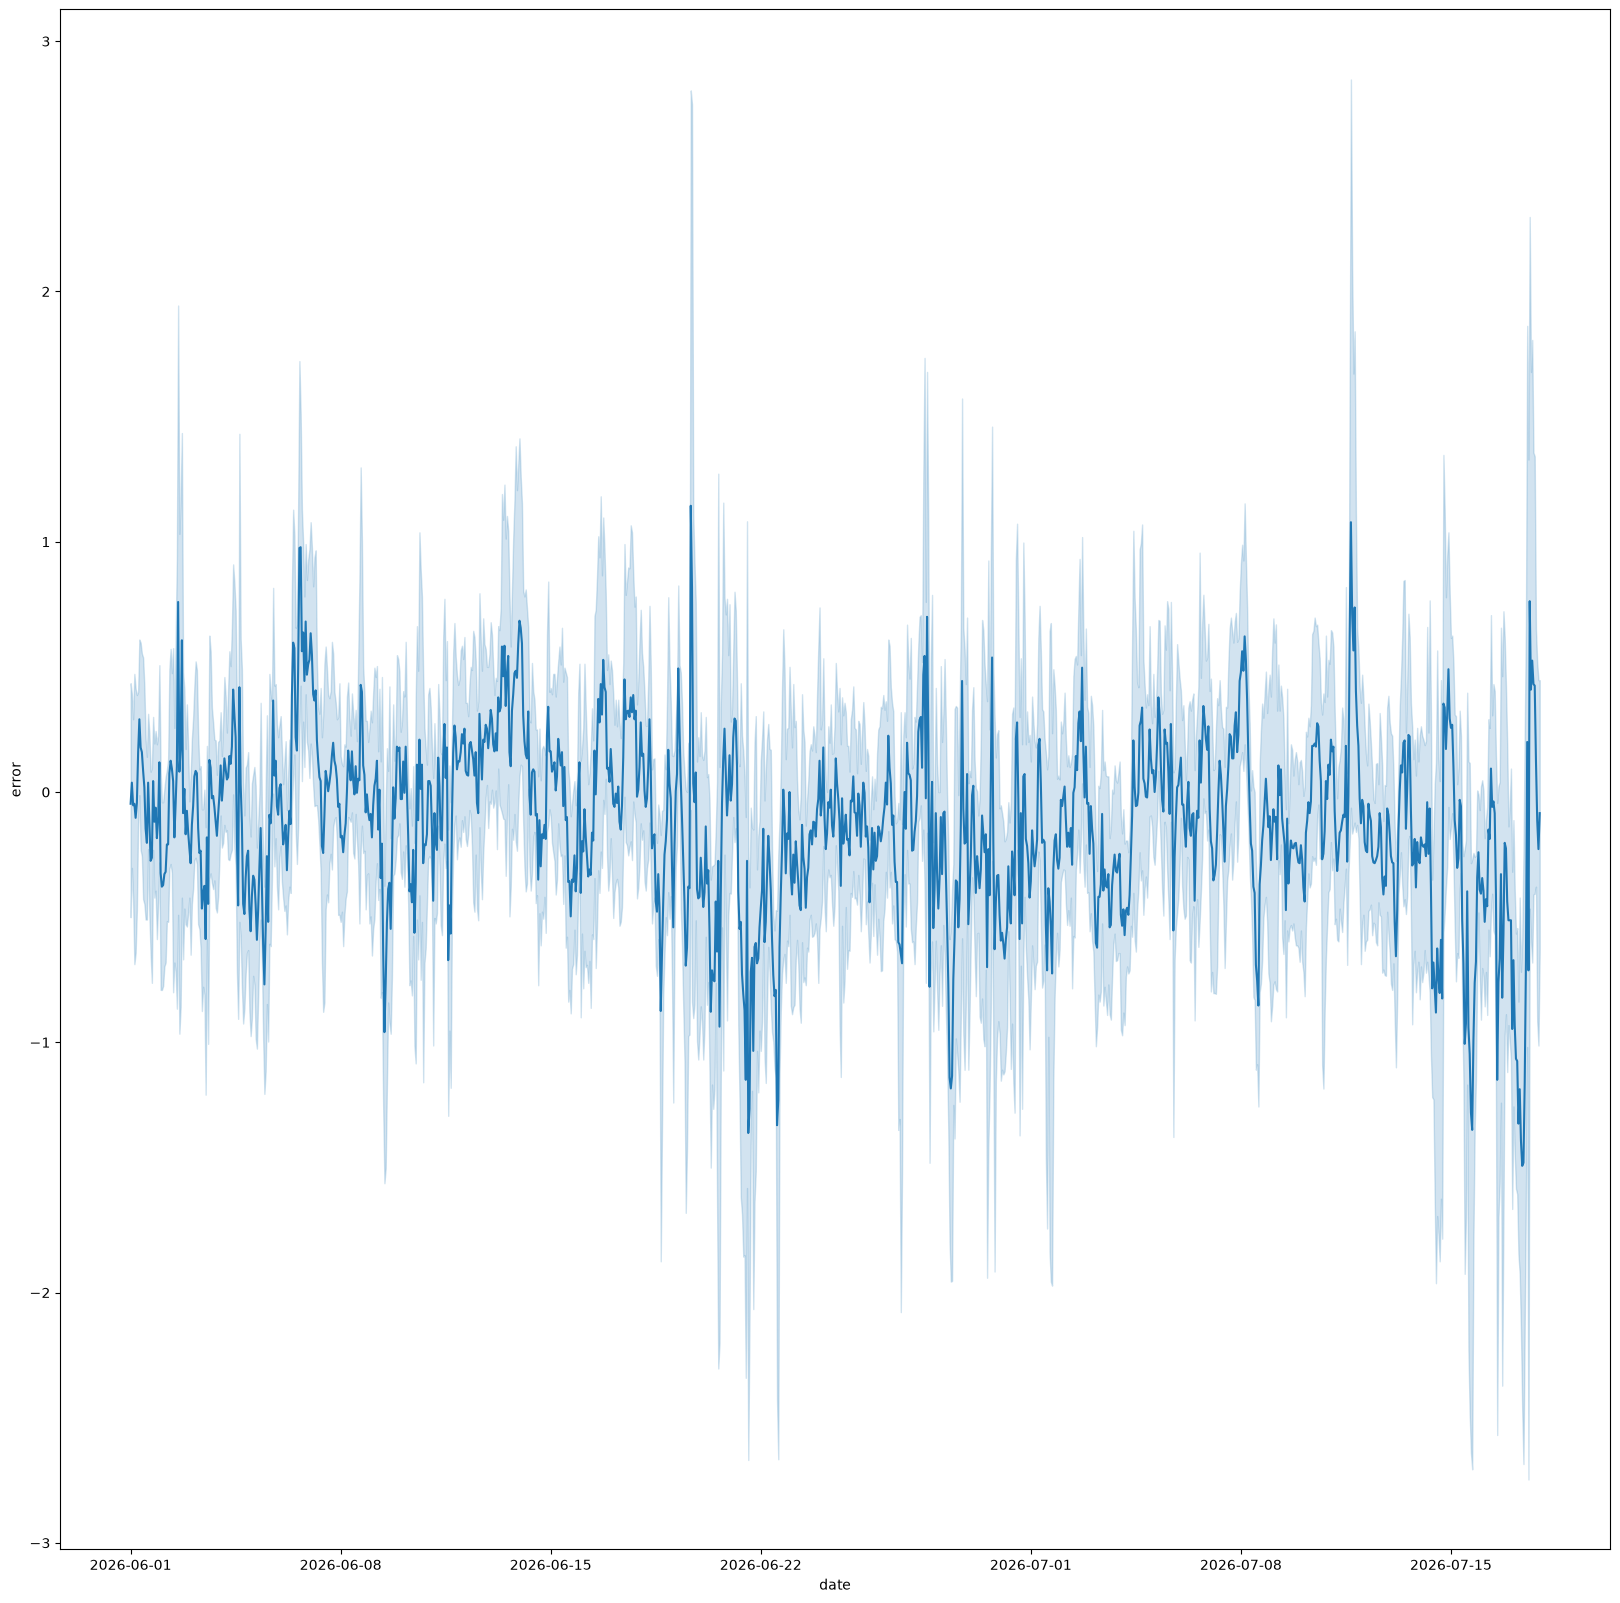

In [6]:


import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,20))
df['error'] = df['temperature_2m'] - df['temperature_2m' + "_previous_day1"]
sns.lineplot(df, x="date", y="error")

In [7]:
df_corr = df.corr()
df_corr['error']

temperature_2m                           -0.022455
direct_normal_irradiance                 -0.016218
diffuse_radiation                        -0.017233
precipitation                            -0.134730
wind_speed_10m                            0.009514
wind_direction_10m                        0.060377
temperature_2m_previous_day1             -0.210654
direct_normal_irradiance_previous_day1   -0.137200
diffuse_radiation_previous_day1          -0.035673
precipitation_previous_day1               0.129470
wind_speed_10m_previous_day1              0.003660
wind_direction_10m_previous_day1          0.040705
latitude                                  0.081082
longitude                                 0.026813
elevation                                -0.003364
day_of_year                              -0.066613
hour_of_day                               0.018785
forecast_horizon                               NaN
error                                     1.000000
Name: error, dtype: float64

## Uncertainty Modeling
### Defining validation function

In [75]:
# defining validation function
from sklearn.metrics import mean_pinball_loss
import numpy as np



def validate(y_test, p05,p50,p95):
    val_dict = {
        'metric': [],
        'target': [],
        'actual': []
    }
    coverage_error = 0
    coverage_count = 0
    coverage = (
        (y_test <= p50) &
        (y_test >= p05)
    ).mean()
    val_dict['metric'].append('P(p05 ≤ Y ≤ p50)')
    val_dict['target'].append('45%')
    val_dict['actual'].append(str(coverage*100) + '%')
    coverage_error += abs(45-coverage*100)
    coverage_count += 1
    
    print("Calibration 05-50:", coverage)
    coverage = (
        (y_test >= p50) &
        (y_test <= p95)
    ).mean()
    val_dict['metric'].append('P(p50 ≤ Y ≤ p95)')
    val_dict['target'].append('45%')
    val_dict['actual'].append(str(coverage*100) + '%')
    coverage_error += abs(45-coverage*100)
    coverage_count += 1
    
    print("Calibration 50-95:", coverage)
    coverage = (
        (y_test >= p05) &
        (y_test <= p95)
    ).mean()
    val_dict['metric'].append('P(p05 ≤ Y ≤ p95)')
    val_dict['target'].append('90%')
    val_dict['actual'].append(str(coverage*100) + '%')
    coverage_error += abs(90-coverage*100)
    coverage_count += 1
    
    print("Calibration 05-95:", coverage)
    coverage_interval = coverage
    coverage = (
        (y_test <= p05)
    ).mean()
    val_dict['metric'].append('P(Y ≤ p05)')
    val_dict['target'].append('5%')
    val_dict['actual'].append(str(coverage*100) + '%')
    print("Calibration <= 05:", coverage)
    
    below_p05 = coverage
    coverage = (
        (y_test >= p95)
    ).mean()
    print("Calibration >=95:", coverage)
    above_p95 = coverage
    coverage_error += abs(5-coverage*100)
    coverage_count += 1
    val_dict['metric'].append('P(p95 ≤ Y)')
    val_dict['target'].append('5%')
    val_dict['actual'].append(str(coverage*100) + '%')

    val_dict['metric'].append('Calibration Error')
    val_dict['target'].append('0')
    val_dict['actual'].append(str(coverage_error/coverage_count) + 'pp%')

    val_dict['metric'].append('Coverage error')
    val_dict['target'].append('0')
    val_dict['actual'].append(str(90 - 100*coverage_interval) + 'pp%')
    
    val_dict['metric'].append('Symmetry Score')
    val_dict['target'].append('1')
    val_dict['actual'].append(str( 1 - abs(below_p05 - above_p95)/(below_p05 + above_p95)))
   
    
    return pd.DataFrame(val_dict)





### Training models function definition

In [72]:


import lightgbm as lgb
validations = {}
def train_and_validate_for_variable(variable):
    print("")
    print("training for variable:", variable)
    zero_variables = ['direct_normal_irradiance', 'diffuse_radiation', 'precipitation']

    
    model_p05 = lgb.LGBMRegressor(
        objective="quantile",
        alpha=0.05,
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        verbosity=-1
    )
    
    model_p50 = lgb.LGBMRegressor(
        objective="quantile",
        alpha=0.50,
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        verbosity=-1
    )
    
    model_p95 = lgb.LGBMRegressor(
        objective="quantile",
        alpha=0.95,
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        verbosity=-1
    )
    thresholds = {
        'direct_normal_irradiance': 0,
        'diffuse_radiation': 0,
        'precipitation': 0.5
    }
    # for irradiance, 0-values cannot be validated by coverage
    # if prediction is 0, all values are zero. Do not train this is model
    if variable in zero_variables:
        my_test = df_test[df_test[variable + previous_day_suffix] > thresholds[variable]]
        my_train = df_train[df_train[variable + previous_day_suffix] > thresholds[variable]]
    else: 
        my_test = df_test
        my_train = df_train

    print("Lenght of training set: ", len(my_train))
        

    X_train,y_train = split_x_y(my_train, variable)
    model_p05.fit(X_train, y_train)
    model_p50.fit(X_train, y_train)
    model_p95.fit(X_train, y_train)

    
    X_test,y_test = split_x_y(my_test, variable)
    p05 = model_p05.predict(X_test)
    p50 = model_p50.predict(X_test)
    p95 = model_p95.predict(X_test)
    
    
    print("validating variable:", variable)
    validations[variable] = validate(y_test, p05,p50,p95)



train_and_validate_for_variable("precipitation")   





training for variable: precipitation
Lenght of training set:  2217
validating variable: precipitation
Calibration 05-50: 0.5328578706062149
Calibration 50-95: 0.34742740703005603
Calibration 05-95: 0.8802852776362711
Calibration <= 05: 0.27101375445746306
Calibration >=95: 0.11971472236372899


### Running Training for every fetched variable

In [76]:
for variable in variables:
    train_and_validate_for_variable(variable)




training for variable: temperature_2m
Lenght of training set:  64128
validating variable: temperature_2m
Calibration 05-50: 0.41414046906187624
Calibration 50-95: 0.43240082335329344
Calibration 05-95: 0.8462917914171657
Calibration <= 05: 0.07436689121756487
Calibration >=95: 0.07934131736526946

training for variable: direct_normal_irradiance
Lenght of training set:  34319
validating variable: direct_normal_irradiance
Calibration 05-50: 0.3897704155768672
Calibration 50-95: 0.4382156349898285
Calibration 05-95: 0.8262423714036617
Calibration <= 05: 0.09003196745132229
Calibration >=95: 0.08398721301947108

training for variable: diffuse_radiation
Lenght of training set:  38179
validating variable: diffuse_radiation
Calibration 05-50: 0.45460966931770613
Calibration 50-95: 0.40267894516534114
Calibration 05-95: 0.8545154876517371
Calibration <= 05: 0.0759470489744663
Calibration >=95: 0.06953746337379657

training for variable: precipitation
Lenght of training set:  2217
validating v

In [77]:
for key, validation in validations.items():
    print('Validation metrics for :' + key)
    display(validation)

Validation metrics for :precipitation


,metric,target,actual
0,P(p05 ≤ Y ≤ p50),45%,53.285787060621495%
1,P(p50 ≤ Y ≤ p95),45%,34.7427407030056%
2,P(p05 ≤ Y ≤ p95),90%,88.02852776362711%
3,P(Y ≤ p05),5%,27.101375445746307%
4,P(p95 ≤ Y),5%,11.971472236372898%
5,Calibration Error,0,6.87149770759042pp%
6,Coverage error,0,1.9714722363728896pp%
7,Symmetry Score,1,0.6127770534550195


Validation metrics for :temperature_2m


,metric,target,actual
0,P(p05 ≤ Y ≤ p50),45%,41.41404690618762%
1,P(p50 ≤ Y ≤ p95),45%,43.24008233532935%
2,P(p05 ≤ Y ≤ p95),90%,84.62917914171658%
3,P(Y ≤ p05),5%,7.436689121756487%
4,P(p95 ≤ Y),5%,7.934131736526946%
5,Calibration Error,0,3.41270583832335pp%
6,Coverage error,0,5.370820858283423pp%
7,Symmetry Score,1,0.9676372121335092


Validation metrics for :direct_normal_irradiance


...

,metric,target,actual
0,P(p05 ≤ Y ≤ p50),45%,45.46096693177061%
1,P(p50 ≤ Y ≤ p95),45%,40.26789451653411%
2,P(p05 ≤ Y ≤ p95),90%,85.45154876517371%
3,P(Y ≤ p05),5%,7.59470489744663%
4,P(p95 ≤ Y),5%,6.953746337379657%
5,Calibration Error,0,2.9238174968606114pp%
6,Coverage error,0,4.548451234826288pp%
7,Symmetry Score,1,0.9559431756878259


Validation metrics for :wind_speed_10m


,metric,target,actual
0,P(p05 ≤ Y ≤ p50),45%,41.74463572854291%
1,P(p50 ≤ Y ≤ p95),45%,43.48958333333333%
2,P(p05 ≤ Y ≤ p95),90%,85.23421906187625%
3,P(Y ≤ p05),5%,7.137287924151696%
4,P(p95 ≤ Y),5%,7.628493013972055%
5,Calibration Error,0,3.0400137225548924pp%
6,Coverage error,0,4.765780938123754pp%
7,Symmetry Score,1,0.966733551589397


Validation metrics for :wind_direction_10m


,metric,target,actual
0,P(p05 ≤ Y ≤ p50),45%,43.28686377245509%
1,P(p50 ≤ Y ≤ p95),45%,42.9500374251497%
2,P(p05 ≤ Y ≤ p95),90%,86.21662924151696%
3,P(Y ≤ p05),5%,6.6897455089820355%
4,P(p95 ≤ Y),5%,7.093625249500998%
5,Calibration Error,0,2.4100237025948124pp%
6,Coverage error,0,3.783370758483045pp%
7,Symmetry Score,1,0.9706980427650186


#### Interpretation
The models deliver already usable results for most variables. However, Zero-Clipped variables that can be easily predicted when they are zero (irradiation at night, precipitation on a dry summer day). Here, a remedy must be found for validating and prediction. Cutting off 0-values out of training and validation could gain some accuracy (must be done in production, too, bypassing the model). Precipitation needs further research.  
The other variables already look usable for a demo application, although in production, when reliability is a cost factor, some further research could be put into the accuracy of the uncertainty prediction.

Metrics show we have a coverage error of 1.9 - 7.3 pp. 

